## **Optimizing Coffee Shop Placement in Makassar**: A Geospatial Data Science Approach using K-Means Clustering and Huff’s Gravity Model 
Oleh: Muh. Afrizal Nur

---

#### **Bussiness Problem (Latar Belakang)**

Pada akhir 2025, jumlah kedai kopi di Indonesia menembus angka 461.991 gerai. Angka ini membuat Indonesia menjadi salah satu negara dengan jumlah kedai kopi terbanyak di dunia. Kedai kopi di Indonesia tersebar ke berbagai provinsi, misalnya Sulawesi Selatan. Menurut data dari GoodStat, total ada 9.848 kedai kopi yang beroperasi di Sulawesi Selatan.  

In [28]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans


In [29]:
data_clean = pd.read_csv('../dataset/data_clean.csv')

In [30]:
data_clean.head()

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
0,Kopi Teori New Chapter,4.7,452,Coffee shop,-5.155283,119.440105,"WARKOP SAMI, Jalan Boulevard, Masale, Panakkuk...",Masale,Panakkukang,Makassar
1,Kopikost - Coffee & Roastery,4.6,128,Coffee shop,-5.144494,119.452607,"Profesor Abdurrahman Basalamah, Karampuang, Pa...",Karampuang,Panakkukang,Makassar
2,Melos Coffee & Eatery,4.3,311,Coffee shop,-5.135454,119.434586,"Jalan Perkebunan, Sinrijala, Panakkukang, Maka...",Sinrijala,Panakkukang,Makassar
3,Institut KOPI,4.7,183,Coffee shop,-5.154309,119.439131,"Jalan Topaz Raya, Masale, Panakkukang, Makassa...",Masale,Panakkukang,Makassar
4,Postropis Coffee & Space,4.8,81,Coffee shop,-5.132992,119.433270,"Jalan Adipura Raya, Tamajeʼneʼ, Karuwisi Utara...",Karuwisi Utara,Panakkukang,Makassar


In [31]:
data_clean.sort_values(by='jumlah_reviewer', ascending=False)

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
752,Lucé Gelato,4.9,3530,Cafe,-5.127119,119.408756,"Toko Cahaya oleh-oleh Makassar, Jalan Lembeh, ...",Ende,Wajo,Makassar
818,Warkop Five One,4.4,2254,Coffee shop,-5.119632,119.509392,"warkop 51, Jalan Puri Yuhana, Puri Yuhana Perm...",Daya,Biringkanaya,Makassar
673,Babathe X Luce Nusantara resto and gelato,5.0,2065,Cafe,-5.126891,119.408432,"Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...",Ende,Wajo,Makassar
904,Warkop Azzahrah - Bandang,4.5,1920,Coffee shop,-5.122904,119.418671,"Warkop Az-zarah, Jalan Bandang I, Parang Layan...",Parang Layang,Bontoala,Makassar
580,Es Putar Papabon,4.5,1849,Coffee shop,-5.140735,119.409328,"Jalan Dg. Tompo, Maloku, Ujung Pandang, Makass...",Maloku,Ujung Pandang,Makassar
...,...,...,...,...,...,...,...,...,...,...
1280,Daico,0.0,0,Coffee shop,-5.159188,119.407646,"Mariso, Makassar, Sulawesi Selatan, Sulawesi, ...",Mariso,Mariso,Makassar
1306,Biz Coffee,0.0,0,Coffee shop,-5.159515,119.413452,"Jalan Opu Daeng Risadju, Mario, Mariso, Makass...",Mario,Mariso,Makassar
1307,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.163502,119.406770,"Jalan Anggrek, Bontorannu, Mariso, Makassar, S...",Bontorannu,Mariso,Makassar
1283,Kopi lounge,0.0,0,Coffee shop,-5.160624,119.407959,"Jalan Seruni, Kampung Buyang, Mariso, Makassar...",Kampung Buyang,Mariso,Makassar


In [32]:
df = data_clean.copy()

## **Analisis Deskriptif**
---

In [33]:
df.describe()

,rating,jumlah_reviewer,lat,long
count,1310.000000,1310.000000,1310.000000,1310.000000
mean,4.463969,106.445038,-5.144628,119.443451
std,1.040912,252.004550,0.023291,0.035453
min,0.000000,0.000000,-5.214848,119.327802
25%,4.500000,5.000000,-5.161365,119.417357
50%,4.700000,21.000000,-5.148688,119.431002
75%,5.000000,89.000000,-5.126659,119.458473
max,5.000000,3530.000000,-5.048941,119.531709


In [34]:
df.sort_values(by="rating")

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota
1309,Teras Ai,0.0,0,Coffee shop,-5.163623,119.408818,"Twinsangel House, 59/15, Jalan Hati Murni, Tam...",Tamarunang,Mariso,Makassar
1307,The Julu Ati Coffee & Garden,0.0,0,Coffee shop,-5.163502,119.406770,"Jalan Anggrek, Bontorannu, Mariso, Makassar, S...",Bontorannu,Mariso,Makassar
1306,Biz Coffee,0.0,0,Coffee shop,-5.159515,119.413452,"Jalan Opu Daeng Risadju, Mario, Mariso, Makass...",Mario,Mariso,Makassar
911,OQ Cafe,0.0,0,Coffee shop,-5.132140,119.426769,"Jalan Mesjid Raya, Timungan Lompoa, Bontoala, ...",Timungan Lompoa,Bontoala,Makassar
1278,KEDAI OH KOPIJOKKA CABANG MERAK,0.0,0,Coffee shop,-5.159561,119.410606,"SD NEG KAKATUA, Jalan Merak, Mariso, Makassar,...",Mariso,Mariso,Makassar
...,...,...,...,...,...,...,...,...,...,...
1291,Kopi Doeloe Cafe,5.0,10,Cafe,-5.161365,119.409364,"DPD RI Makassar, Jalan Nuri, Kampung Buyang, M...",Kampung Buyang,Mariso,Makassar
1290,Street Kopi,5.0,1,Coffee shop,-5.151922,119.410601,"Jalan Rajawali, Panambungan, Mariso, Makassar,...",Panambungan,Mariso,Makassar
1289,Kopi Kalosi,5.0,1,Coffee shop,-5.149632,119.412910,"Jalan Opu Daeng Risadju, Kunjung Mae, Mariso, ...",Kunjung Mae,Mariso,Makassar
76,Mall Panakkukang,5.0,2,Coffee shop,-5.157871,119.446699,Pizza Hut Restoran - Panakkukang Mall Makassar...,Masale,Panakkukang,Makassar


## **Market Saturation**

In [35]:
df.groupby(by='kecamatan', dropna=True).count()

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kota
kecamatan,,,,,,,,,
Biringkanaya,118,118,118,118,118,118,118,118,118
Bontoala,58,58,58,58,58,58,58,58,58
Kepulauan Sangkarrang,2,2,2,2,2,2,2,2,2
Makassar,40,40,40,40,40,40,40,40,40
Mamajang,108,108,108,108,108,108,108,108,108
Manggala,104,104,104,104,104,104,104,104,104
Mariso,106,106,106,106,106,106,106,106,106
Panakkukang,111,111,111,111,111,111,111,111,111
Rappocini,145,145,145,145,145,145,145,145,145


In [39]:
df.groupby(by='kecamatan')

In [41]:
df_agg = df.groupby(by='kecamatan').agg(
    count_toko=('nama', 'count'),              # Menghitung jumlah toko (baris)
    total_reviewer=('jumlah_reviewer', 'sum'), # Menjumlahkan semua reviewer
)

In [45]:
df_agg

,count_toko,total_reviewer
kecamatan,,
Biringkanaya,118,9875
Bontoala,58,4373
Kepulauan Sangkarrang,2,0
Makassar,40,7756
Mamajang,108,12212
Manggala,104,4076
Mariso,106,8312
Panakkukang,111,18498
Rappocini,145,18126


In [47]:
df_agg.to_csv('../dataset/data_agg.csv')

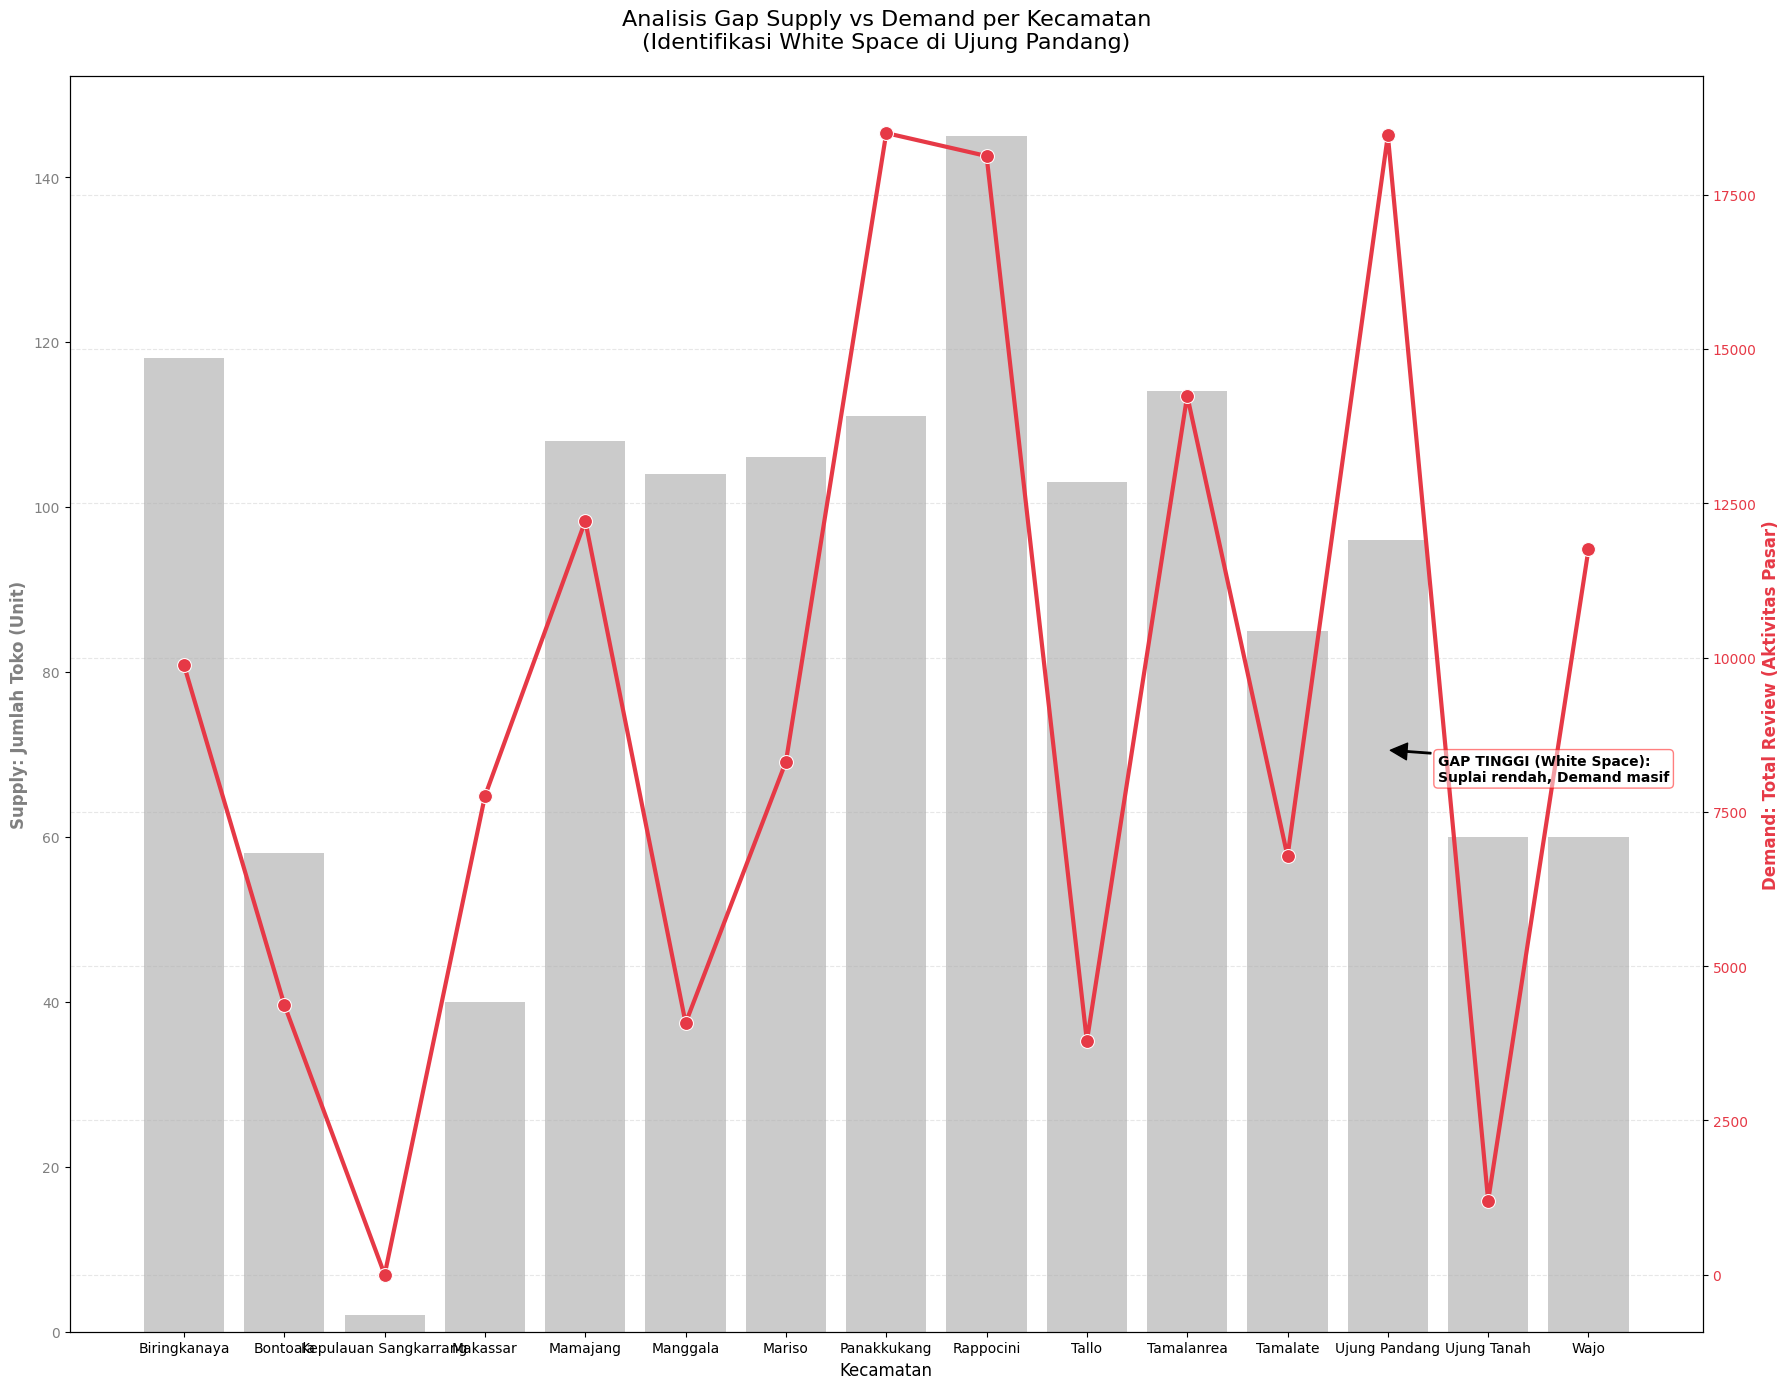

In [59]:
# Warna estetik untuk portfolio
color_supply = '#A9A9A9' # Abu-abu untuk Supply (Toko)
color_demand = '#E63946' # Merah untuk Demand (Review)

# A. Bar Chart untuk JUMLAH TOKO (Sumbu Y Kiri)
fig, ax1 = plt.subplots(figsize=(18, 14))

sns.barplot(x=df_agg.index, y='count_toko', data=df_agg, ax=ax1, color=color_supply, alpha=0.6)
ax1.set_ylabel('Supply: Jumlah Toko (Unit)', fontsize=12, color='gray', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='gray')

# B. Line + Points untuk TOTAL REVIEW (Sumbu Y Kanan)
ax2 = ax1.twinx() # Membuat sumbu Y kedua
sns.lineplot(x=df_agg.index, y='total_reviewer', data=df_agg, ax=ax2, color=color_demand, marker='o', linewidth=3, markersize=10)
ax2.set_ylabel('Demand: Total Review (Aktivitas Pasar)', fontsize=12, color=color_demand, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_demand)

# C. Dekorasi dan Insight
plt.title('Analisis Gap Supply vs Demand per Kecamatan\n(Identifikasi White Space di Ujung Pandang)', fontsize=16, pad=20)
ax1.set_xlabel('Kecamatan', fontsize=12)

# Tambahkan Anomali Highlight untuk Ujung Pandang
plt.annotate('GAP TINGGI (White Space):\nSuplai rendah, Demand masif', 
             xy=(12, 8500), xytext=(12.5, 8000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round", fc="w", ec="red", alpha=0.5))


plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../assets/supply_demand_gap_analysis.png', dpi=300)
plt.show()


In [ ]:
# ANALISIS PENETRASI PER KECAMATAN
def market_saturation_analysis(df):
    # A. Menghitung Absolute Density (Jumlah Toko per Wilayah)
    saturation_df = df.groupby('kecamatan').agg(
        jumlah_toko=('nama', 'count'),
        rata_rata_rating=('rating', 'mean'),
        total_reviewer=('jumlah_reviewer', 'sum')
    ).reset_index()

    # B. Menghitung Market Share Potential (Proxy)
    # Semakin tinggi reviewer di suatu kecamatan, semakin tinggi 'Demand' di sana
    total_market_reviews = saturation_df['total_reviewer'].sum()
    saturation_df['market_share_demand_%'] = (saturation_df['total_reviewer'] / total_market_reviews) * 100

    # C. Menghitung Saturation Index (SI)
    # Logika: Jika jumlah toko banyak tapi reviewer sedikit = Sangat Jenuh (Over-supplied)
    # Jika jumlah toko sedikit tapi reviewer banyak = Peluang Tinggi (Under-supplied)
    saturation_df['saturation_index'] = saturation_df['jumlah_toko'] / np.log1p(saturation_df['total_reviewer'])
    
    return saturation_df.sort_values(by='saturation_index', ascending=False)

# Eksekusi Analisis
saturation_results = market_saturation_analysis(df)

print("--- Hasil Analisis Saturasi Pasar Makassar ---")
print(saturation_results[['kecamatan', 'jumlah_toko', 'saturation_index', 'market_share_demand_%']])

# IDENTIFIKASI WHITE SPACE (Area Potensial)
# Kita cari kecamatan dengan jumlah toko rendah tapi Demand (Reviewer) lumayan tinggi
white_space = saturation_results[
    (saturation_results['jumlah_toko'] < saturation_results['jumlah_toko'].median()) & 
    (saturation_results['market_share_demand_%'] > 10)
]

print("\n--- Rekomendasi White Space (Peluang Tinggi) ---")
if white_space.empty:
    print("Tidak ditemukan area white space yang dominan, disarankan ekspansi ke area satelit.")
else:
    print(white_space['kecamatan'].tolist())

--- Hasil Analisis Saturasi Pasar Makassar ---
                kecamatan  jumlah_toko  saturation_index  \
2   Kepulauan Sangkarrang            2               inf   
8               Rappocini          145         14.788135   
0            Biringkanaya          118         12.829067   
5                Manggala          104         12.510350   
9                   Tallo          103         12.501819   
10             Tamalanrea          114         11.919673   
6                  Mariso          106         11.744403   
4                Mamajang          108         11.476839   
7             Panakkukang          111         11.297167   
12          Ujung Pandang           96          9.772568   
11               Tamalate           85          9.635296   
13            Ujung Tanah           60          8.464523   
1                Bontoala           58          6.918407   
14                   Wajo           60          6.402084   
3                Makassar           40          4.466

#### **Rasio Supply and Demand**

**Insight**
- Kecamatan **Ujung Pandang** menjadi rekomendasi lokasi yang dapat dipilih untuk membuat coffee shop di Kota Makassar. Hal ini dikarenakan Kecamatan Ujung Pandang merupakan area dengan **High Volume** dan **Low Density**. Hal ini diidentifikasi melalui indeks saturasi yang rendah, di mana meskipun wilayah ini memiliki kepadatan Point of Interest (POI) yang tinggi, rasio jumlah unit usaha terhadap volume aktivitas digital (jumlah reviewer) masih jauh di bawah rata-rata kota, mengindikasikan adanya permintaan (demand) masif yang belum terlayani secara optimal.
- Di Ujung Pandang (daerah Somba Opu, Losari, Sudirman), jumlah coffee shop mungkin kalah banyak secara angka absolut dibandingkan Rappocini. Namun, jumlah Footfall (arus manusia) di sini adalah yang tertinggi di Makassar, dikarenakan kecamatan Ujung Pandang merupakan pusta kota yang strategis berfungsi sebagai pusat pemerintahan, perdagangan, dan pariwisata.

**Nice to Know**
- Harga sewa lahan di Ujung Pandang sangat mahal. Hal ini menyebabkan Supply (toko) tidak tumbuh secepat di pinggiran kota.
- Ini adalah White Space bagi investor bermodal kuat. Persaingan di sini bukan lagi soal harga murah, tapi soal Prestige dan Convenience.

### **Kondisi Coffee Shop di Ujung Pandang**

In [ ]:
def calculate_bayesian_rating(df):
    C = np.nanmean(df['rating'].values)
    m = np.mean(df['jumlah_reviewer'].values)

    bayesian_rating = ((m * C) + (df["jumlah_reviewer"] * df["rating"]) ) / (m + df["jumlah_reviewer"])

    return bayesian_rating

In [ ]:
df['bayesian_rating'] = calculate_bayesian_rating(df)

In [ ]:
top_3 = df[df['kecamatan'] == 'Ujung Pandang'].sort_values(by='bayesian_rating', ascending=False)[:3]

In [ ]:
top_3

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,bayesian_rating
556,Onkel John's Coffee Hasanuddin,4.8,227,Coffee shop,-5.140776,119.410609,"Fore Coffee, 53, Jalan Sultan Hasanuddin, Sawe...",Sawerigading,Ujung Pandang,Makassar,4.692730
607,Goodfields Makassar,4.7,1276,Cafe,-5.139557,119.410714,"Hawker Resto, Jalan Chairil Anwar, Sawerigadin...",Sawerigading,Ujung Pandang,Makassar,4.681826
558,MyCoffee,4.7,646,Coffee shop,-5.136396,119.407541,"Black Canyon, Jalan Pattimura, Bulogading, Uju...",Bulogading,Ujung Pandang,Makassar,4.666610


### **Komentar Netizen**

#### **1. Onkel John's Coffee Hasanuddin**

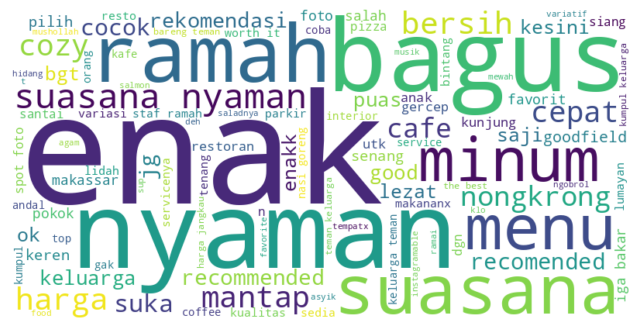

## **Visualisasi Sebaran**
---

Tujuan: *Hotspots*: Di mana titik-titik merah (kumpulan kedai kopi terbanyak)?

In [ ]:
df['popularity_score'] = df['rating'] * np.log1p(df['jumlah_reviewer'])

# 3. K-MEANS CLUSTERING
# Menentukan zona berdasarkan lokasi (Lat, Long)
X = df[['lat', 'long']]
kmeans = KMeans(n_clusters=3, random_state=42) # Sesuaikan jumlah cluster (k)
df['cluster'] = kmeans.fit_predict(X)

# 4. VISUALISASI PETA INTERAKTIF (Folium)
# Titik tengah Makassar
makassar_coord = [-5.147, 119.432]
f = folium.Figure(width=1000, height=500)

m = folium.Map(location=makassar_coord, zoom_start=13, tiles='OpenStreetMap').add_to(f)

# A. Tambahkan Heatmap (Visualisasi Saturasi/Kejenuhan)
heat_data = [[row['lat'], row['long']] for index, row in df.iterrows()]
HeatMap(heat_data, name="Heatmap Saturasi").add_to(m)

# B. Tambahkan Marker untuk setiap Toko
for i, row in df.iterrows():
    # Warna marker berdasarkan cluster
    colors = ['red', 'blue', 'green', 'purple', 'orange']
    color = colors[row['cluster'] % len(colors)]
    
    popup_text = f"""
    <b>{row['nama']}</b><br>
    Rating: {row['rating']}<br>
    Kecamatan: {row['kecamatan']}<br>
    Review: {row['jumlah_reviewer']}<br>
    Score: {row['popularity_score']:.2f}
    """
    
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=7,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=200)
    ).add_to(m)
m.save('../assets/chart/analisis_geomarketing_makassar.html')
print("Analisis selesai! Buka file 'analisis_geomarketing_makassar.html' di browser Anda.")
m

Analisis selesai! Buka file 'analisis_geomarketing_makassar.html' di browser Anda.


In [ ]:
df.sort_values(by="popularity_score", ascending=False)

,nama,rating,jumlah_reviewer,tipe,lat,long,alamat,kelurahan,kecamatan,kota,bayesian_rating,popularity_score,cluster
752,Lucé Gelato,4.9,3530,Cafe,-5.127119,119.408756,"Toko Cahaya oleh-oleh Makassar, Jalan Lembeh, ...",Ende,Wajo,Makassar,4.887237,40.029748,2
673,Babathe X Luce Nusantara resto and gelato,5.0,2065,Cafe,-5.126891,119.408432,"Indomaret, Jalan Lembeh, Ende, Wajo, Makassar,...",Ende,Wajo,Makassar,4.973724,38.166848,2
904,Warkop Azzahrah - Bandang,4.5,1920,Coffee shop,-5.122904,119.418671,"Warkop Az-zarah, Jalan Bandang I, Parang Layan...",Parang Layang,Bontoala,Makassar,4.498107,34.022705,2
818,Warkop Five One,4.4,2254,Coffee shop,-5.119632,119.509392,"warkop 51, Jalan Puri Yuhana, Puri Yuhana Perm...",Daya,Biringkanaya,Makassar,4.402885,33.971983,1
63,kopiteori,4.6,1597,Coffee shop,-5.157261,119.419732,"Jalan Beruang, Bonto Biraeng, Mamajang, Makass...",Bonto Biraeng,Mamajang,Makassar,4.591500,33.931937,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,Kopi lounge,0.0,0,Coffee shop,-5.160624,119.407959,"Jalan Seruni, Kampung Buyang, Mariso, Makassar...",Kampung Buyang,Mariso,Makassar,4.463969,0.000000,0
682,Kopi Abang,0.0,0,Coffee shop,-5.111969,119.421228,"Jalan Sabutung, Gusung, Ujung Tanah, Makassar,...",Gusung,Ujung Tanah,Makassar,4.463969,0.000000,2
1264,Kopi Seduhu,0.0,0,Coffee store,-5.162441,119.406800,"Jalan Dahlia, Mattoangin, Mariso, Makassar, Su...",Mattoangin,Mariso,Makassar,4.463969,0.000000,0
484,Kopi cinnaku,0.0,0,Coffee shop,-5.169717,119.447619,"Jalan Tamalate 3, Perumnas Tamalate, Kassiʼ-Ka...",Kassi-Kassi,Rappocini,Makassar,4.463969,0.000000,0


In [ ]:
df['kecamatan'].value_counts()

kecamatan
Rappocini                145
Biringkanaya             118
Tamalanrea               114
Panakkukang              111
Mamajang                 108
Mariso                   106
Manggala                 104
Tallo                    103
Ujung Pandang             96
Tamalate                  85
Wajo                      60
Ujung Tanah               60
Bontoala                  58
Makassar                  40
Kepulauan Sangkarrang      2
Name: count, dtype: int64

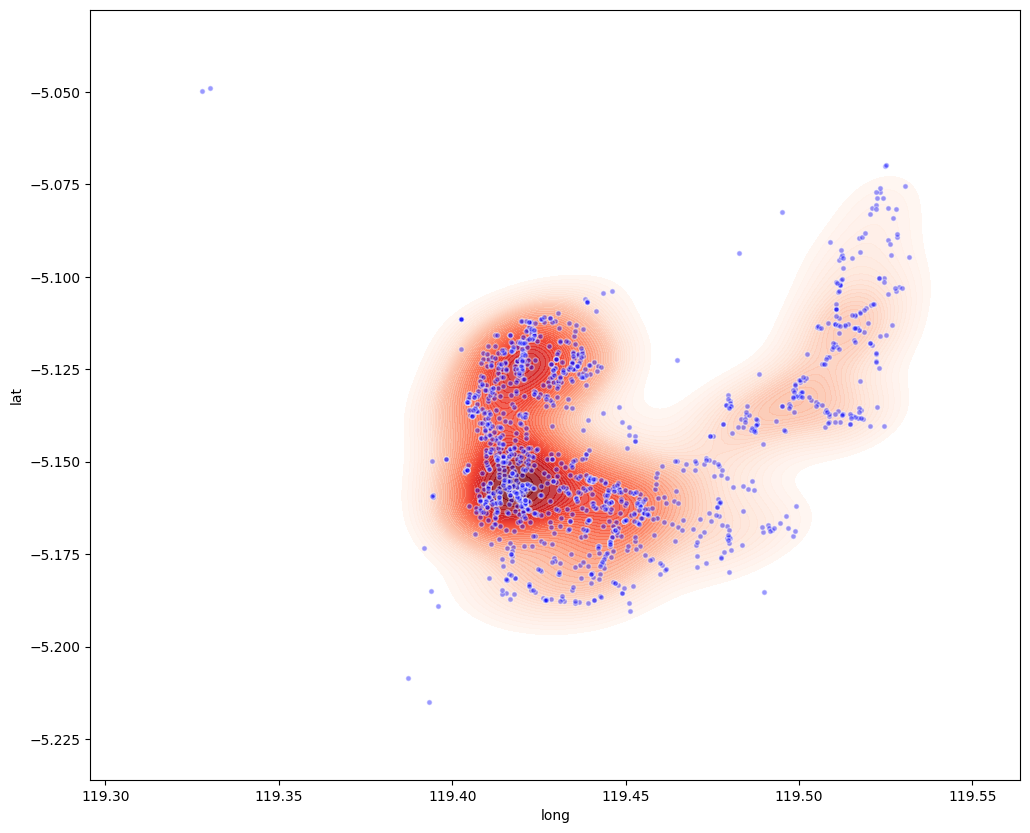

In [ ]:
plt.figure(figsize=(12, 10))

sns.kdeplot(x=df['long'],
                 y=df['lat'],
                 fill=True,
                 thresh=0.05,
                 levels=50,
                 cmap="Reds",
                 alpha=0.8)

plt.scatter(df['long'],
            df['lat'],
            s=15,
            color='blue',
            alpha=0.4,
            edgecolors='white',
            label='Titik Coffee Shop')

plt.show()